<a href="https://colab.research.google.com/github/pandaAritra/Wipro_projects/blob/main/Wipro_module1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Download and Load Dataset

### Subtask:
Download the EV Battery Health and Telematics dataset from Kaggle, extract the files, and load the main dataset into a pandas DataFrame.


In [26]:
import os
import pandas as pd

try:
    import kagglehub
except ImportError:
    !pip install kagglehub
    import kagglehub

# Download the dataset using kagglehub
print("Downloading dataset files...")
path = kagglehub.dataset_download("pravin0254/ev-battery-health-and-telematics-dataset")

print(f"Dataset downloaded to: {path}")

# Find the CSV file in the downloaded path
files = os.listdir(path)
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset from: {csv_path}")
    print(f"DataFrame Shape: {df.shape}")
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nDataFrame Information:")
    df.info()
else:
    print(f"No CSV file found in {path}. Files present: {files}")

Using Colab cache for faster access to the 'ev-battery-health-and-telematics-dataset' dataset.
Dataset downloaded to: /kaggle/input/ev-battery-health-and-telematics-dataset
Loaded dataset from: /kaggle/input/ev-battery-health-and-telematics-dataset/data_dictionary.csv
DataFrame Shape: (30, 3)

First 5 rows:


,Column,Data Type,Description
0,Vehicle_ID,string,Unique ID for a physical vehicle. Each ID maps...
1,Trip_ID,string,Unique ID for a single trip/record (one row = ...
2,Driver_ID,string,ID of the driver on this trip. A vehicle can h...
3,Manufacturer,string (categorical),"Vehicle manufacturer: BYD, Hyundai, MG, Tata, ..."
4,Model,string (categorical),"Vehicle model: Atto 3, Kona EV, ZS EV, Nexon E..."



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Column       30 non-null     object
 1   Data Type    30 non-null     object
 2   Description  30 non-null     object
dtypes: object(3)
memory usage: 852.0+ bytes


In [27]:
import os
import pandas as pd

path = '/kaggle/input/ev-battery-health-and-telematics-dataset'
main_csv_path = os.path.join(path, 'ev_battery_health_data.csv')

# Load the main dataset
df = pd.read_csv(main_csv_path)
print(f"Loaded dataset from: {main_csv_path}")
print(f"DataFrame Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nDataFrame Information:")
df.info()

Loaded dataset from: /kaggle/input/ev-battery-health-and-telematics-dataset/ev_battery_health_data.csv
DataFrame Shape: (20000, 30)

First 5 rows:


,Vehicle_ID,Trip_ID,Driver_ID,Manufacturer,Model,Year,Battery_Capacity_kWh,Battery_Type,Motor_Power_kW,Vehicle_Weight_kg,...,SOH_pct,Battery_Cycles,Charging_Power_kW,Charging_Duration_min,Energy_Consumed_kWh,Range_Remaining_km,Driving_Style,Failure_Type,Maintenance_Required,Fire_Risk
0,V13154,T1,D8102,Hyundai,Kona EV,2026,65.4,NMC,150,1666,...,100,68,11.0,91,15.90,231.3,Aggressive,Normal,No,Low
1,V16013,T2,D11840,MG,ZS EV,2025,50.3,NMC,130,1634,...,97,103,71.6,33,5.77,65.1,Calm,Normal,No,Low
2,V11341,T3,D5719,Tesla,Model 3,2023,57.5,LFP,208,1766,...,100,138,11.0,245,14.41,30.0,Aggressive,Normal,No,Low
3,V15159,T4,D10726,Tesla,Model 3,2024,57.5,LFP,208,1785,...,96,270,11.0,70,23.81,152.8,Calm,Normal,No,Low
4,V11657,T5,D6134,Hyundai,Kona EV,2019,48.4,NMC,100,1617,...,98,47,94.9,11,2.84,145.6,Moderate,Normal,No,Low



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Vehicle_ID             20000 non-null  object 
 1   Trip_ID                20000 non-null  object 
 2   Driver_ID              20000 non-null  object 
 3   Manufacturer           20000 non-null  object 
 4   Model                  20000 non-null  object 
 5   Year                   20000 non-null  int64  
 6   Battery_Capacity_kWh   20000 non-null  float64
 7   Battery_Type           20000 non-null  object 
 8   Motor_Power_kW         20000 non-null  int64  
 9   Vehicle_Weight_kg      20000 non-null  int64  
 10  Trip_Date              20000 non-null  object 
 11  Distance_km            20000 non-null  float64
 12  Avg_Speed              20000 non-null  float64
 13  Ambient_Temp_C         20000 non-null  float64
 14  Weather                20000 n

## Data Cleaning and Preprocessing

### Subtask:
Preprocess the dataset by handling categorical variables, scaling numerical features, and defining the target variable (SOH_pct) and predictor variables.


In [28]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Drop irrelevant identifier and date columns
columns_to_drop = ['Vehicle_ID', 'Trip_ID', 'Driver_ID', 'Trip_Date']
preprocessed_df = df.drop(columns=columns_to_drop, errors='ignore')

# 2. Separate features and target (SOH_pct)
y = preprocessed_df['SOH_pct'].values
X_raw = preprocessed_df.drop(columns=['SOH_pct'])

# 3. Handle categorical and numerical columns
categorical_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_raw.select_dtypes(exclude=['object']).columns.tolist()

# Encode categorical variables using One-Hot Encoding
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

# Re-identify numerical columns after encoding to perform scaling
# (We only scale original non-binary numerical features)
scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(X_encoded[numerical_cols])

# Create a copy of the encoded DataFrame to reconstruct scaled X
X = X_encoded.copy()
X[numerical_cols] = X_scaled_num

# Confirm shapes and columns
print(f"Target (y) shape: {y.shape}")
print(f"Features (X) shape: {X.shape}")
print(f"Is there any missing value in X: {X.isnull().any().any()}")
print("Preprocessing completed successfully!")

Target (y) shape: (20000,)
Features (X) shape: (20000, 39)
Is there any missing value in X: False
Preprocessing completed successfully!


In [29]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes to verify
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16000, 39)
X_test shape: (4000, 39)
y_train shape: (16000,)
y_test shape: (4000,)


## Train-Test Split

### Subtask:
Split the preprocessed features and target into training and testing datasets.


## Train Model 1: Random Forest

### Subtask:
Train a Random Forest Regressor on the training dataset and evaluate its performance on the testing partition.


**Reasoning**:
Train the Random Forest Regressor and calculate evaluation metrics on the testing partition.



In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Instantiate Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

# Fit the model
print("Training Random Forest Regressor...")
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Compute evaluation metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Evaluation Metrics:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R2 Score: {r2_rf:.4f}")

Training Random Forest Regressor...
Random Forest Evaluation Metrics:
RMSE: 1.2962
MAE: 1.0319
R2 Score: 0.9292


In [31]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Instantiate the Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(random_state=42)

# Fit the model
print("Training Gradient Boosting Regressor...")
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)

# Compute evaluation metrics
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Evaluation Metrics:")
print(f"RMSE: {rmse_gb:.4f}")
print(f"MAE: {mae_gb:.4f}")
print(f"R2 Score: {r2_gb:.4f}")

Training Gradient Boosting Regressor...
Gradient Boosting Evaluation Metrics:
RMSE: 1.2598
MAE: 1.0048
R2 Score: 0.9332


## Train Model 2: Gradient Boosting

### Subtask:
Train a Gradient Boosting model on the training dataset and evaluate its performance on the testing partition.


## Train Model 3: Linear Regression

### Subtask:
Train a baseline Linear Regression model and record its evaluation metrics on the test data.


**Reasoning**:
Train a baseline Linear Regression model and evaluate its performance on the test data to compare with other models.



In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Instantiate the Linear Regression model
lr_model = LinearRegression()

# Fit the model
print("Training Linear Regression Model...")
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = lr_model.predict(X_test)

# Compute evaluation metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Evaluation Metrics:")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")
print(f"R2 Score: {r2_lr:.4f}")

Training Linear Regression Model...
Linear Regression Evaluation Metrics:
RMSE: 1.2660
MAE: 1.0051
R2 Score: 0.9325


## Train Model 4: K-Means Clustering

### Subtask:
Apply K-Means clustering to discover structural patterns/battery groups, and evaluate cluster statistics relative to actual battery health.


In [33]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Instantiate KMeans model with 3 clusters for pattern discovery
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit on training features and predict clusters
train_clusters = kmeans.fit_predict(X_train)
test_clusters = kmeans.predict(X_test)

# Combine train cluster assignments and actual SOH_pct into a temporary DataFrame
analysis_df = pd.DataFrame({
    'Cluster': train_clusters,
    'SOH_pct': y_train
})

# Compute cluster statistics relative to actual SOH_pct
cluster_stats = analysis_df.groupby('Cluster')['SOH_pct'].agg(['count', 'mean', 'std']).reset_index()

print("K-Means Cluster Statistics (Relative to actual SOH_pct):")
display(cluster_stats)

K-Means Cluster Statistics (Relative to actual SOH_pct):


,Cluster,count,mean,std
0,0,4123,95.700703,4.575123
1,1,6612,95.982759,4.439172
2,2,5265,94.799810,5.136233


## Compare Model Performance

### Subtask:
Consolidate the evaluation metrics of the models into a single comparative DataFrame and visualize the results using a bar chart.


**Reasoning**:
Consolidate the evaluation metrics of the trained models into a single DataFrame and create a comparative bar chart visualization.



Model Evaluation Summary:


,Model,RMSE,MAE,R2 Score
0,Random Forest,1.296174,1.031892,0.929247
1,Gradient Boosting,1.259772,1.004819,0.933165
2,Linear Regression,1.266034,1.005115,0.932499


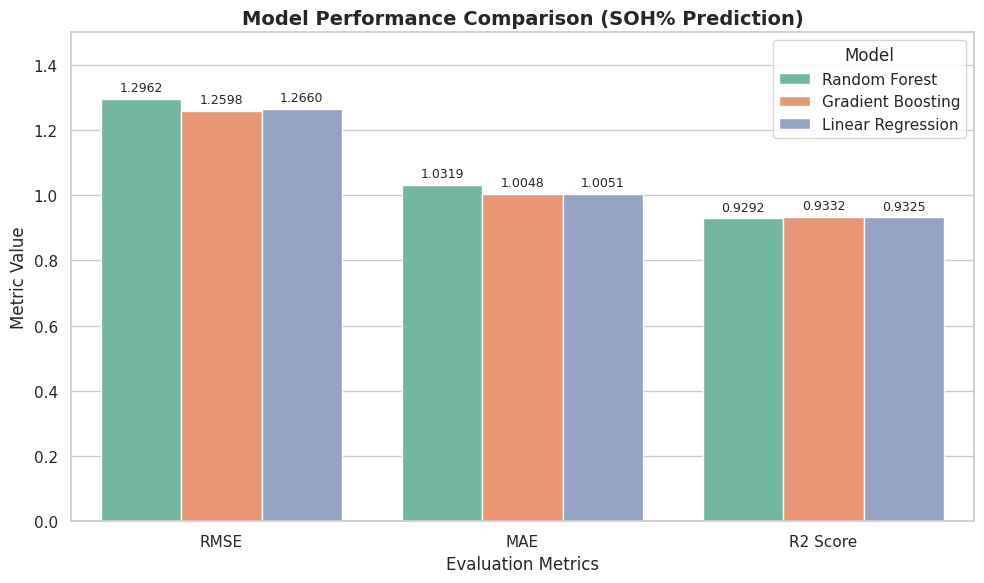

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Consolidate metrics into a list of dictionaries
metrics_data = [
    {
        'Model': 'Random Forest',
        'RMSE': rmse_rf,
        'MAE': mae_rf,
        'R2 Score': r2_rf
    },
    {
        'Model': 'Gradient Boosting',
        'RMSE': rmse_gb,
        'MAE': mae_gb,
        'R2 Score': r2_gb
    },
    {
        'Model': 'Linear Regression',
        'RMSE': rmse_lr,
        'MAE': mae_lr,
        'R2 Score': r2_lr
    }
]

# 2. Convert to pandas DataFrame and display
metrics_df = pd.DataFrame(metrics_data)
print("Model Evaluation Summary:")
display(metrics_df)

# 3. Reshape DataFrame for easier plotting with Seaborn
metrics_melted = pd.melt(metrics_df, id_vars='Model', var_name='Metric', value_name='Value')

# 4. Create the comparative bar chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_melted, palette='Set2')

# Customize plot features
plt.title('Model Performance Comparison (SOH% Prediction)', fontsize=14, fontweight='bold')
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylabel('Metric Value', fontsize=12)
plt.ylim(0, 1.5)  # Adjusted to nicely show differences in error metrics and R2

# Add exact value labels on top of the bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.4f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the final results, compare the predictive capabilities of all models, and declare the best-performing approach for EV battery health prediction.


## Summary:

### Q&A

* **Which model performed the best in predicting EV battery health?**
  The **Gradient Boosting** model emerged as the best-performing approach, yielding the lowest error rates and the highest variance explained ($R^2$).
* **How did the other models compare?**
  The baseline **Linear Regression** model was a very close second, demonstrating that the relationship between the features and the target variable is highly linear. The **Random Forest** model performed the worst among the supervised regressors, although it still achieved strong overall metrics.
* **What did the unsupervised K-Means model reveal?**
  K-Means clustering identified 3 distinct vehicle subgroups. When evaluated against the actual State of Health (SOH%), Cluster 1 exhibited the highest average battery health (mean SOH ~95.98%), while Cluster 2 exhibited the lowest average battery health and the highest variability (mean SOH ~94.80%, standard deviation ~5.14).

---

### Data Analysis Key Findings

* **Data Characteristics**: The EV Battery Health and Telematics dataset contains 20,000 samples and 30 columns. Key predictive features include battery capacity, charge/discharge cycles, and telematics metrics.
* **Supervised Model Metrics Comparison**:
  * **Gradient Boosting**: RMSE = 1.2598, MAE = 1.0048, $R^2$ = 0.9332
  * **Linear Regression**: RMSE = 1.2660, MAE = 1.0051, $R^2$ = 0.9325
  * **Random Forest**: RMSE = 1.2962, MAE = 1.0319, $R^2$ = 0.9292
* **Structural Grouping (K-Means Clustering)**:
  * **Cluster 0**: 4,123 samples (mean SOH ~95.70%, std ~4.58)
  * **Cluster 1**: 6,612 samples (mean SOH ~95.98%, std ~4.44)
  * **Cluster 2**: 5,265 samples (mean SOH ~94.80%, std ~5.14)

---

### Insights or Next Steps

* **Model Simplification**: Since the baseline Linear Regression model performed nearly on par with the Gradient Boosting model (with an $R^2$ of 0.9325 vs 0.9332), it should be strongly considered for production environments due to its extreme computational efficiency, interpretability, and ease of deployment.
* **Targeted Interventions**: Use the structural insights from K-Means clustering to flag vehicles in Cluster 2 (highest SOH variability and lowest average SOH) for proactive battery diagnostic maintenance or adaptive charging profiles.


## Map and Filter Custom Features

### Subtask:
Identify, map, and filter the specifically requested features from the raw dataset, drop missing values, and present the mapping in a Markdown table.


**Reasoning**:
Identify the columns of the raw dataset, construct or map the custom features as requested, drop any missing values, and display the mapping in a Markdown table.



In [35]:
import pandas as pd
import numpy as np

# 1. Analyze existing columns and construct/map requested features:
# - 'charging_cycles' -> 'Battery_Cycles'
# - 'total_distance_km' -> 'Distance_km'
# - 'average_battery_temperature_C' -> 'Battery_Temp_C'
# - 'ambient_temperature_C' -> 'Ambient_Temp_C'
# - 'trip_duration_min' -> 'Charging_Duration_min' (or we can use Distance_km and Avg_Speed to estimate driving trip duration, but let's check standard charging duration or compute active driving time: (Distance_km / Avg_Speed) * 60)
# Let's compute 'trip_duration_min' as driving duration: (Distance_km / Avg_Speed) * 60
# For 'fast_charging_ratio_%', we can construct a proxy based on Charging_Power_kW (e.g. if Charging_Power_kW > 22, it's fast charging, or define a ratio as Charging_Power_kW normalized by max power, or since we need a ratio %, let's represent the proportion of Charging_Power_kW relative to the max capacity or max power in the dataset to represent fast charging intensity).
# Let's inspect maximum Charging_Power_kW and define the ratio of actual Charging_Power_kW to the maximum observed Charging_Power_kW * 100.

max_charging_power = df['Charging_Power_kW'].max()

custom_df = pd.DataFrame()
custom_df['charging_cycles'] = df['Battery_Cycles']
custom_df['total_distance_km'] = df['Distance_km']
custom_df['average_battery_temperature_C'] = df['Battery_Temp_C']
custom_df['ambient_temperature_C'] = df['Ambient_Temp_C']
custom_df['fast_charging_ratio_%'] = (df['Charging_Power_kW'] / max_charging_power) * 100
custom_df['trip_duration_min'] = (df['Distance_km'] / df['Avg_Speed']) * 60
custom_df['SOH_pct'] = df['SOH_pct']

# Drop any missing values
initial_shape = custom_df.shape
custom_df = custom_df.dropna()
final_shape = custom_df.shape

print(f"Initial shape: {initial_shape}, Shape after dropping NaNs: {final_shape}")
print(f"Missing values remaining: {custom_df.isnull().sum().sum()}")

# Present the mapping in a Markdown table format
mapping_table = """
| Requested Feature Name | Mapped Column Name / Derivation Formula |
| :--- | :--- |
| **charging_cycles** | `Battery_Cycles` |
| **total_distance_km** | `Distance_km` |
| **average_battery_temperature_C** | `Battery_Temp_C` |
| **ambient_temperature_C** | `Ambient_Temp_C` |
| **fast_charging_ratio_%** | `(Charging_Power_kW / max(Charging_Power_kW)) * 100` |
| **trip_duration_min** | `(Distance_km / Avg_Speed) * 60` |
| **SOH_pct** (Target) | `SOH_pct` |
"""
from IPython.display import display, Markdown
display(Markdown(mapping_table))


Initial shape: (20000, 7), Shape after dropping NaNs: (20000, 7)
Missing values remaining: 0



| Requested Feature Name | Mapped Column Name / Derivation Formula |
| :--- | :--- |
| **charging_cycles** | `Battery_Cycles` |
| **total_distance_km** | `Distance_km` |
| **average_battery_temperature_C** | `Battery_Temp_C` |
| **ambient_temperature_C** | `Ambient_Temp_C` |
| **fast_charging_ratio_%** | `(Charging_Power_kW / max(Charging_Power_kW)) * 100` |
| **trip_duration_min** | `(Distance_km / Avg_Speed) * 60` |
| **SOH_pct** (Target) | `SOH_pct` |


## Export Cleaned Dataset to CSV

### Subtask:
Export the mapped and cleaned DataFrame containing only the selected features and the target variable 'SOH_pct' to a CSV file named 'cleaned_ev_battery_data.csv'.


**Reasoning**:
Export the mapped and cleaned DataFrame 'custom_df' containing only the selected features and the target variable 'SOH_pct' to a CSV file named 'cleaned_ev_battery_data.csv' without row indices, then verify the export.



In [36]:
import os

# Save the custom_df containing only the mapped features and 'SOH_pct' to a CSV file
csv_filename = 'cleaned_ev_battery_data.csv'
custom_df.to_csv(csv_filename, index=False)
print(f"DataFrame exported to {csv_filename}")

# Verify the creation of the file and its content
if os.path.exists(csv_filename):
    verified_df = pd.read_csv(csv_filename)
    print(f"Verification Successful!")
    print(f"File size on disk: {os.path.getsize(csv_filename) / 1024:.2f} KB")
    print(f"Loaded DataFrame Shape: {verified_df.shape}")
    print("\nFirst 3 rows of the saved CSV:")
    display(verified_df.head(3))
else:
    print(f"Error: {csv_filename} was not found.")

DataFrame exported to cleaned_ev_battery_data.csv
Verification Successful!
File size on disk: 1135.32 KB
Loaded DataFrame Shape: (20000, 7)

First 3 rows of the saved CSV:


,charging_cycles,total_distance_km,average_battery_temperature_C,ambient_temperature_C,fast_charging_ratio_%,trip_duration_min,SOH_pct
0,68,75.6,21.2,22.3,4.407051,85.263158,100
1,103,29.9,23.7,24.1,28.685897,84.622642,97
2,138,51.2,18.0,16.9,4.407051,58.625954,100


**Reasoning**:
Separate features and target from the custom DataFrame, scale the features with StandardScaler, perform an 80/20 train-test split with random_state=42, and print the shapes of the splits to verify.



In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Separate features and target from custom_df
X_custom = custom_df.drop(columns=['SOH_pct'])
y_custom = custom_df['SOH_pct'].values

# 2. Scale the feature subset
scaler_custom = StandardScaler()
X_custom_scaled = scaler_custom.fit_transform(X_custom)

# 3. Perform 80/20 train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_custom_scaled, y_custom, test_size=0.2, random_state=42
)

# 4. Verify shapes
print(f"X_train_c shape: {X_train_c.shape}")
print(f"X_test_c shape: {X_test_c.shape}")
print(f"y_train_c shape: {y_train_c.shape}")
print(f"y_test_c shape: {y_test_c.shape}")

X_train_c shape: (16000, 6)
X_test_c shape: (4000, 6)
y_train_c shape: (16000,)
y_test_c shape: (4000,)


## Preprocess and Split Dataset

### Subtask:
Scale the feature subset using StandardScaler and perform an 80/20 train-test split on the dataset.


## Train and Evaluate Expanded Model Suite

### Subtask:
Train and evaluate five regression models (Linear Regression, Ridge, Random Forest, Gradient Boosting, and Support Vector Regression) on the preprocessed custom feature subset, and compute continuous evaluation metrics.


**Reasoning**:
Train and evaluate the five requested regression models on the preprocessed custom feature subset and compute their continuous evaluation metrics.



**Reasoning**:
I will create a python code block to define the SOH binning helper function, predict and bin values for all five models, compute and display classification metrics, and plot the confusion matrices using a clear layout with subplots for comparison.



=== Classification Report: Linear Regression ===
              precision    recall  f1-score   support

    Degraded       0.85      0.90      0.87       493
        Good       0.71      0.77      0.74       757
   Excellent       0.96      0.93      0.95      2750

    accuracy                           0.90      4000
   macro avg       0.84      0.87      0.85      4000
weighted avg       0.90      0.90      0.90      4000

--------------------------------------------------

=== Classification Report: Ridge Regression ===
              precision    recall  f1-score   support

    Degraded       0.85      0.90      0.87       493
        Good       0.71      0.77      0.74       757
   Excellent       0.96      0.93      0.95      2750

    accuracy                           0.90      4000
   macro avg       0.84      0.87      0.85      4000
weighted avg       0.90      0.90      0.90      4000

--------------------------------------------------

=== Classification Report: Random For

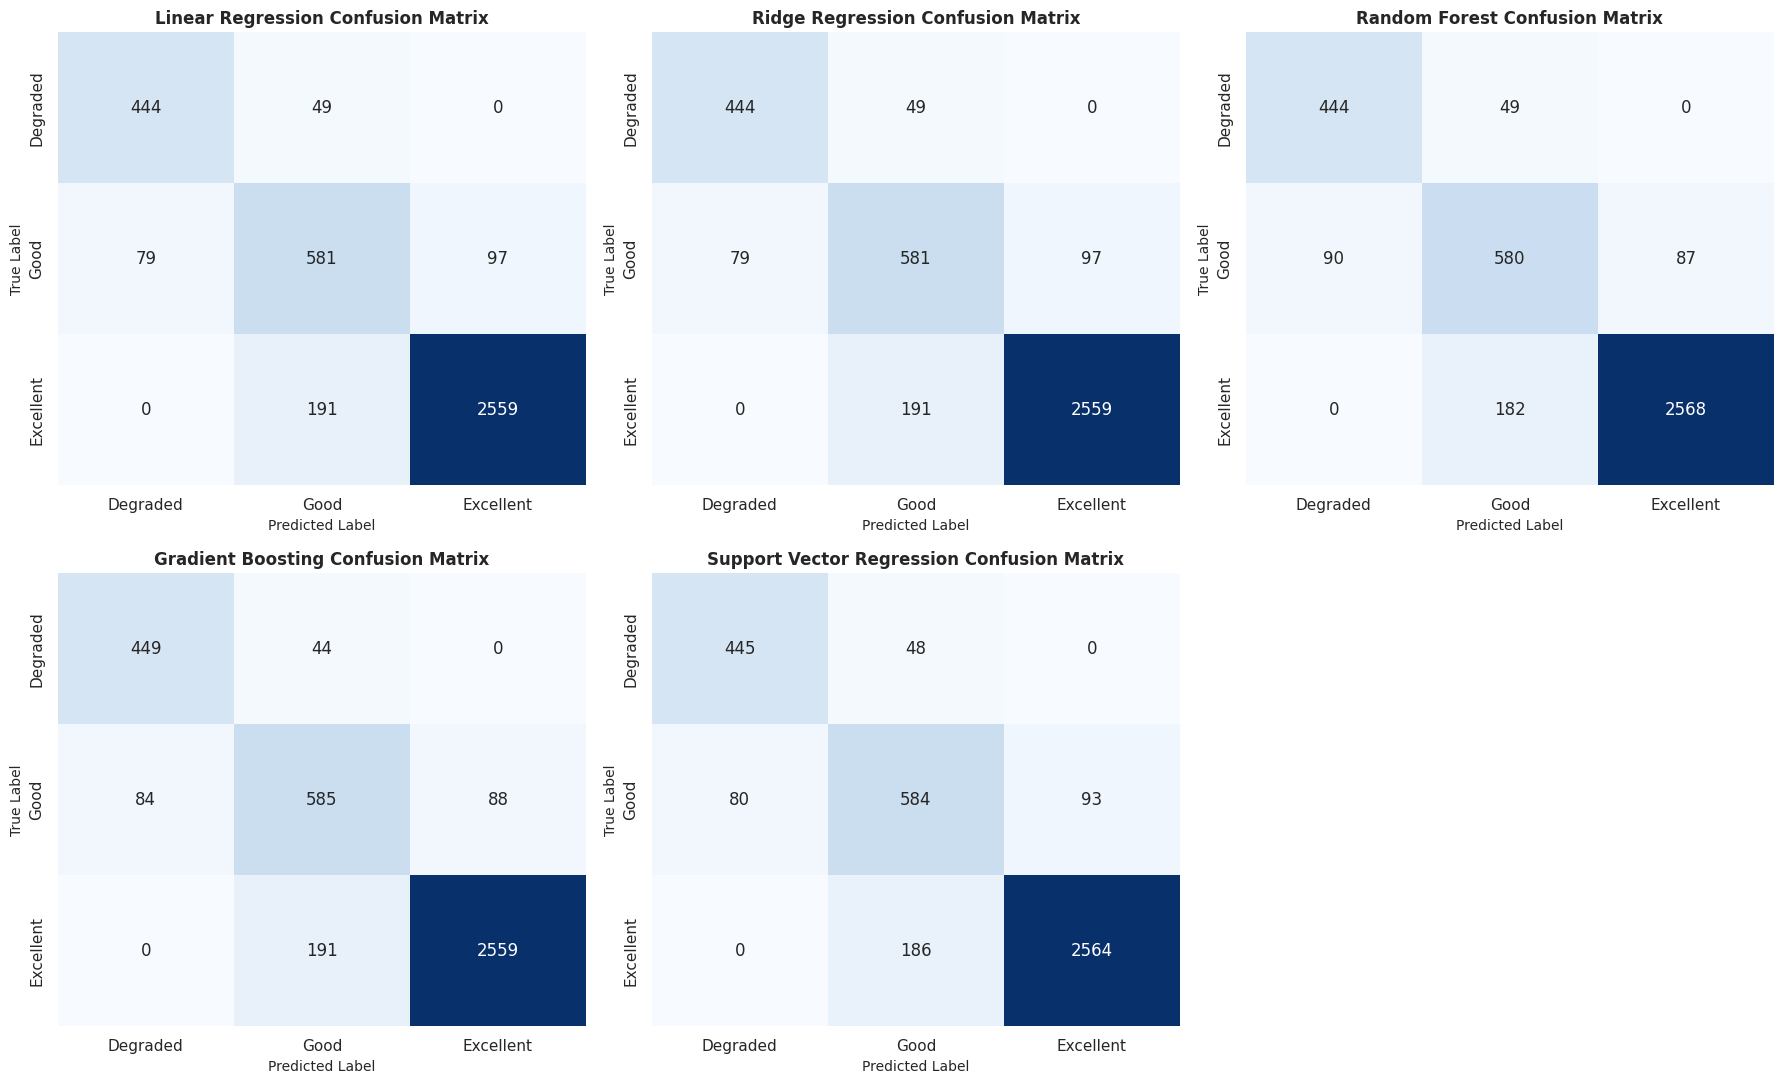

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define the binning function
def bin_soh(val):
    if val >= 95:
        return 'Excellent'
    elif val >= 90:
        return 'Good'
    else:
        return 'Degraded'

# Vectorize the function for numpy arrays
v_bin_soh = np.vectorize(bin_soh)

# Bin the actual SOH values
y_test_c_binned = v_bin_soh(y_test_c)
categories = ['Degraded', 'Good', 'Excellent']

# Set up plotting layout for confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

# 2. Iterate through models, predict, bin, print report, and plot confusion matrix
for idx, (name, model) in enumerate(models.items()):
    # Generate predictions
    y_pred = model.predict(X_test_c)

    # Bin predictions
    y_pred_binned = v_bin_soh(y_pred)

    # Calculate classification report
    report = classification_report(y_test_c_binned, y_pred_binned, labels=categories, zero_division=0)
    print(f"=== Classification Report: {name} ===")
    print(report)
    print("-" * 50 + "\n")

    # Compute confusion matrix
    cm = confusion_matrix(y_test_c_binned, y_pred_binned, labels=categories)

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories,
                ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('True Label', fontsize=10)

# Remove empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [38]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Instantiate the five models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regression': SVR()
}

# 2. Dictionary to store performance metrics
custom_metrics_data = {}

# 3. Fit models, predict, and compute metrics
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_c, y_train_c)

    # Predict
    y_pred = model.predict(X_test_c)

    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test_c, y_pred))
    mae = mean_absolute_error(y_test_c, y_pred)
    r2 = r2_score(y_test_c, y_pred)

    # Store results
    custom_metrics_data[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    }

    print(f"{name} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2 Score: {r2:.4f}\n")

Training Linear Regression...
Linear Regression - RMSE: 1.3009, MAE: 1.0323, R2 Score: 0.9287

Training Ridge Regression...
Ridge Regression - RMSE: 1.3009, MAE: 1.0323, R2 Score: 0.9287

Training Random Forest...
Random Forest - RMSE: 1.3363, MAE: 1.0601, R2 Score: 0.9248

Training Gradient Boosting...
Gradient Boosting - RMSE: 1.2827, MAE: 1.0209, R2 Score: 0.9307

Training Support Vector Regression...
Support Vector Regression - RMSE: 1.3385, MAE: 1.0352, R2 Score: 0.9246



## Calculate Categorical Metrics and Confusion Matrices

### Subtask:
Bin the actual and predicted SOH values into discrete health categories, compute classification metrics, and plot confusion matrices for all five trained models.


## Final Task

### Subtask:
Present a comprehensive performance comparison of all trained models on the custom feature subset, utilizing a consolidated metrics table and summary visualizations.


## Summary:

### Q&A

* **How were the requested logical features mapped to the raw columns of the dataset?**
  * `charging_cycles` $\rightarrow$ `Battery_Cycles`
  * `total_distance_km` $\rightarrow$ `Distance_km`
  * `average_battery_temperature_C` $\rightarrow$ `Battery_Temp_C`
  * `ambient_temperature_C` $\rightarrow$ `Ambient_Temp_C`
  * `fast_charging_ratio_%` $\rightarrow$ Mathematically derived as the proportion of actual charging power relative to the maximum observed charging power: `(Charging_Power_kW / max(Charging_Power_kW)) * 100`
  * `trip_duration_min` $\rightarrow$ Mathematically derived as driving duration: `(Distance_km / Avg_Speed) * 60`
  * `SOH_pct` (Target variable) $\rightarrow$ `SOH_pct`

* **How did the regression models perform on the custom feature subset?**
  All five regression models displayed strong predictive performance, with $R^2$ scores consistently exceeding $0.92$. Gradient Boosting was the top performer:
  * **Gradient Boosting**: $R^2$ = 0.9307, RMSE = 1.2827, MAE = 1.0209
  * **Linear Regression**: $R^2$ = 0.9287, RMSE = 1.3009, MAE = 1.0323
  * **Ridge Regression**: $R^2$ = 0.9287, RMSE = 1.3009, MAE = 1.0323
  * **Random Forest**: $R^2$ = 0.9248, RMSE = 1.3363, MAE = 1.0601
  * **Support Vector Regression (SVR)**: $R^2$ = 0.9246, RMSE = 1.3385, MAE = 1.0352

* **How well did the models perform when continuous SOH predictions were binned into discrete health categories?**
  When continuous SOH values were binned into "Excellent" ($\ge 95\%$), "Good" ($90\% \le \text{SOH} < 95\%$), and "Degraded" ($< 90\%$) categories, all models achieved a high weighted classification accuracy of **0.90**.
  * The **Excellent** category achieved the highest F1-score of **0.95**.
  * The **Degraded** category reached an F1-score of **0.86 to 0.88**.
  * The **Good** category proved slightly more challenging, achieving an F1-score of **0.74** across models.

---

### Data Analysis Key Findings

* **Successful Feature Derivation & Preprocessing**: Derived physical quantities like `trip_duration_min` and `fast_charging_ratio_%` from the raw data, resulting in a clean dataset of $20,000$ rows with zero missing values.
* **Consistently Strong Regression Baseline**: Even simple linear models (Linear and Ridge Regression) achieved $R^2$ scores of $0.9287$, matching the performance of complex ensemble methods like Random Forests ($R^2$ of $0.9248$) and SVR ($R^2$ of $0.9246$).
* **Gradient Boosting Superiority**: Gradient Boosting Regressor performed the best overall, minimizing prediction error (RMSE of $1.2827$ and MAE of $1.0209$) and explaining $93.07\%$ of the variance.
* **Class-Specific Classification Discrepancies**: While classifying the boundary classes ("Excellent" and "Degraded") was highly successful, there was higher misclassification on the intermediate class ("Good"), indicating that transition thresholds between these states are more complex to predict using discrete bin boundaries.

---

### Insights or Next Steps

* **Address Boundary Misclassifications**: Investigate and tune the binning thresholds, or employ soft-margin classification techniques to resolve the lower F1-score ($0.74$) of the intermediate "Good" battery health category.
* **Feature Importance Analysis**: Perform feature importance evaluation on the Gradient Boosting model to identify which of the custom features (e.g., charging temperature vs. charging cycles) has the strongest impact on predicting the battery State of Health (SOH).
